# Tutorial 13-4: The Search Engine – "Multimodal RAG with CLIP"

**Course:** CSEN 342: Deep Learning  
**Topic:** Retrieval Augmented Generation (RAG), Vector Embeddings, and Semantic Search

## Objective
Large Language Models (LLMs) cannot see your entire hard drive of photos. To build an AI that can "search" your memories, we need a **Retrieval System**.

In this tutorial, we will build a **Multimodal RAG (Retrieval Augmented Generation)** pipeline.

**The Workflow:**
1.  **Index:** Create a database of images and convert them into **Vector Embeddings** using **CLIP**. CLIP maps images and text to the same vector space.
2.  **Retrieve:** When the user asks a question (e.g., "Show me the delicious food"), we find the image with the highest **Cosine Similarity** to the text.
3.  **Generate:** We pass that specific image to a Captioning Model (**BLIP**) to describe it.

*NOTE*: Run this notebook in the `Transformers Bundle` and on a `gpu` with 32G of VRAM.

---

## Part 1: Building the Image Database

First, we simulate a database by defining a list of image URLs (diverse categories: animals, landmarks, food).

We use `transformers` to load **CLIP** (for embeddings) and **BLIP** (for captioning).

In [1]:
import torch
import requests
from PIL import Image
from io import BytesIO
from transformers import CLIPProcessor, CLIPModel, BlipProcessor, BlipForConditionalGeneration
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Load CLIP (The Retriever)
# CLIP maps text and images to the same 512-dimensional vector space.
print("Loading CLIP...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# 2. Load BLIP (The Generator)
# BLIP is a small, fast model for Image Captioning and VQA.
print("Loading BLIP...")
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

print("Models Loaded.")

Loading CLIP...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Models Loaded.


---

## Part 2: Indexing (Creating Embeddings)

We download the images and run them through CLIP to get their vector representations ($V$). We store these vectors in a simple list (our "Vector Database").

In [2]:
# Our "Database" of URLs
image_urls = [
    "http://images.cocodataset.org/val2017/000000039769.jpg", # Cats
    "https://www.ilankelman.org/stopsigns/australia.jpg",     # Stop Sign
    "https://cdn.pixabay.com/photo/2017/12/09/08/18/pizza-3007395_1280.jpg", # Pizza
    "https://cdn.pixabay.com/photo/2016/11/29/04/19/ocean-1867285_1280.jpg", # Beach
    "https://cdn.pixabay.com/photo/2014/11/30/14/11/cat-551554_1280.jpg",    # Another Cat
    "https://cdn.pixabay.com/photo/2016/01/19/17/29/earth-1149733_1280.jpg"  # Earth from space
]

images = []
image_embeddings = []

print("Indexing images... (Downloading and Embedding)")

for url in image_urls:
    # Download
    try:
        resp = requests.get(url, stream=True)
        img = Image.open(BytesIO(resp.content)).convert("RGB")
        images.append(img)
        
        # Embed with CLIP
        inputs = clip_processor(images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            # get_image_features returns the [1, 512] vector
            embed = clip_model.get_image_features(**inputs)
            # Normalize the embedding (crucial for cosine similarity)
            embed = embed / embed.norm(p=2, dim=-1, keepdim=True)
            image_embeddings.append(embed)
            
    except Exception as e:
        print(f"Failed to download {url}: {e}")

# Stack into one tensor: Shape [N_Images, 512]
image_embeddings = torch.cat(image_embeddings, dim=0)
print(f"Indexed {len(images)} images. Embedding Shape: {image_embeddings.shape}")

Indexing images... (Downloading and Embedding)
Failed to download https://cdn.pixabay.com/photo/2016/01/19/17/29/earth-1149733_1280.jpg: cannot identify image file <_io.BytesIO object at 0x7f057014ca40>
Indexed 5 images. Embedding Shape: torch.Size([5, 512])


---

## Part 3: The Search Engine (Retrieval)

Now we implement the search logic.
1.  Take a text query ($T$).
2.  Embed it with CLIP: $v_{text} = \text{CLIP}(T)$.
3.  Calculate similarity: $S = v_{text} \cdot V_{images}^T$ (Dot Product).
4.  Pick the image with the highest score.

In [3]:
def search(query_text, k=1):
    """
    Returns the indices of the top-k images matching the query.
    """
    # 1. Embed Text
    inputs = clip_processor(text=[query_text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_embed = clip_model.get_text_features(**inputs)
        # Normalize
        text_embed = text_embed / text_embed.norm(p=2, dim=-1, keepdim=True)
    
    # 2. Similarity Search (Dot Product)
    # (1, 512) x (N, 512)^T -> (1, N)
    similarity = (text_embed @ image_embeddings.T)
    
    # 3. Get Top K
    values, indices = similarity[0].topk(k)
    
    return indices.cpu().numpy(), values.cpu().numpy()

## Part 4: The RAG Loop (Generate)

We combine retrieval with generation. 
**User Query:** "Is there any healthy food?"
**Agent:** 
1.  Finds the "Pizza" image (closest to food).
2.  Passes it to BLIP to generate a caption.
3.  Displays the result.


--- Query: 'A delicious meal' ---
Retrieval: Found image index 2 (Similarity: 0.2311)


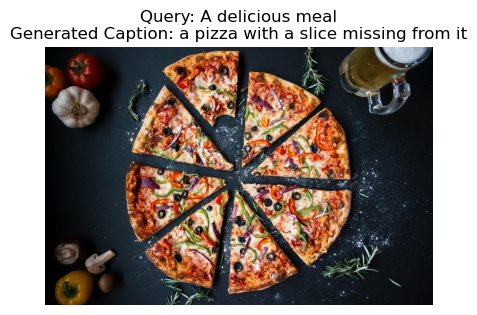


--- Query: 'Something dangerous' ---
Retrieval: Found image index 4 (Similarity: 0.2176)


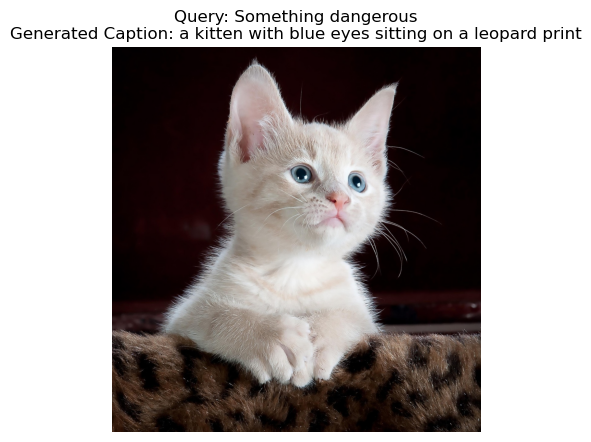


--- Query: 'A view from space' ---
Retrieval: Found image index 3 (Similarity: 0.1954)


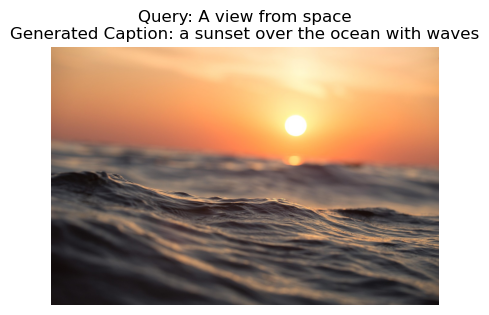


--- Query: 'A cute animal' ---
Retrieval: Found image index 4 (Similarity: 0.2661)


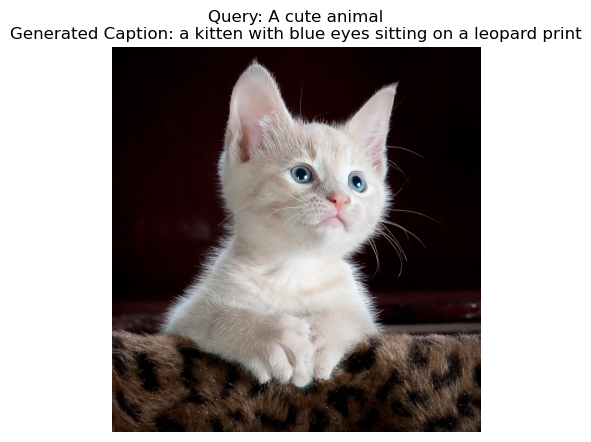

In [4]:
def multimodal_rag(query):
    print(f"\n--- Query: '{query}' ---")
    
    # 1. Retrieve
    idx, score = search(query, k=1)
    best_image_idx = idx[0]
    best_image = images[best_image_idx]
    
    print(f"Retrieval: Found image index {best_image_idx} (Similarity: {score[0]:.4f})")
    
    # 2. Generate (Captioning)
    # We ask BLIP to describe the retrieved image
    inputs = blip_processor(images=best_image, return_tensors="pt").to(device)
    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=50)
    caption = blip_processor.decode(out[0], skip_special_tokens=True)
    
    # 3. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(best_image)
    plt.axis('off')
    plt.title(f"Query: {query}\nGenerated Caption: {caption}")
    plt.show()

# Test Cases
multimodal_rag("A delicious meal")
multimodal_rag("Something dangerous") # Should find stop sign or maybe earth?
multimodal_rag("A view from space")
multimodal_rag("A cute animal")

### Conclusion

You have implemented a semantic search engine!

**Why is this powerful?**
1.  **Zero-Shot:** We didn't train on "Pizza" or "Space". CLIP's pre-training allows it to understand these concepts out of the box.
2.  **Scalability:** In a real application, you would replace our simple list with a **Vector Database** (like Pinecone, Milvus, or FAISS), allowing you to search billions of images in milliseconds.

This is the backbone of modern Multimodal RAG systems used in enterprise search and digital asset management.